# Corporate Event Extraction from SEC 8-K Filings at Scale

**Chapter 23: Knowledge Graphs for Financial AI** | Section 23.7

> **Neo4j + GPU required**: This notebook needs a Neo4j graph database and GPU
> for NER/embedding models:
> ```bash
> docker compose --profile kg up -d neo4j
> docker compose run --rm ml4t-gpu python 23_knowledge_graphs/08_8k_event_extraction.py
> ```


This notebook demonstrates large-scale event extraction from SEC 8-K filings,
using batch LLM inference and the FinReflectKG reflection methodology to
construct a corporate event knowledge graph.

**Learning Objectives**:
- Extract structured event quadruples (subject, relation, object, timestamp) from 8-K filings
- Implement the FinReflectKG critic-corrector reflection loop for quality assurance
- Load event graphs into Neo4j using efficient UNWIND batch operations
- Write temporal Cypher queries over corporate event data

**Book Reference**: Chapter 23, Section 23.7 (Case Study: Corporate Events from 8-K)

**Prerequisites**: Familiarity with `supply_chain_kg_construction` notebook;
requires Neo4j for graph loading and a GPU-backed Qwen model for extraction.

In [1]:
"""Corporate Event Extraction from SEC 8-K Filings at Scale — batch LLM extraction of corporate event graphs."""

from __future__ import annotations

import contextlib
import json
import os
import re
from dataclasses import dataclass, field
from datetime import UTC, datetime

import matplotlib.pyplot as plt
import polars as pl
import torch

from data import DataNotFoundError, load_sec_filings
from utils.style import COLORS

In [2]:
# Production defaults — Papermill overrides for testing.
# The staged SP100 8-K corpus ships with ~1,249 filings × 101 SP100 companies × 2020-2025.
# The notebook narrative is calibrated to a 50-filing demo for tractability.
# Set MAX_FILINGS=0 to process the entire staged corpus (~10x runtime).
MAX_FILINGS = 50

# LLM model — local HuggingFace transformers checkpoint loaded onto CUDA.
#   Default: Qwen/Qwen2.5-7B-Instruct (fp16 ~14 GB, fits 24 GB GPU comfortably).
#   Alt:     Qwen/Qwen3-8B            (fp16 ~16 GB; native thinking mode).
# Set ENABLE_THINKING=True only with a Qwen3 family model — Qwen2.5 ignores it.
# Bump MAX_NEW_TOKENS to ~2048 when ENABLE_THINKING=True (CoT eats tokens).
MODEL_NAME = "Qwen/Qwen2.5-7B-Instruct"
ENABLE_THINKING = False
MAX_NEW_TOKENS = 512

# Batch size for LLM inference
BATCH_SIZE = 4  # Smaller than supply chain due to longer prompts

In [3]:
# Parameters
MAX_FILINGS = 0
MODEL_NAME = "Qwen/Qwen3-8B"
ENABLE_THINKING = False
MAX_NEW_TOKENS = 512


## Infrastructure Detection

Detect available infrastructure: GPU for Qwen2.5-7B, Neo4j for graph storage.

In [4]:
# GPU availability for LLM
GPU_AVAILABLE = torch.cuda.is_available()
print(f"GPU available: {GPU_AVAILABLE}")
if GPU_AVAILABLE:
    print(f"  Device: {torch.cuda.get_device_name(0)}")
    print(f"  Memory: {torch.cuda.get_device_properties(0).total_memory / 1e9:.1f} GB")

GPU available: True
  Device: NVIDIA GeForce RTX 3090
  Memory: 25.3 GB


In [5]:
# Neo4j connection settings (from environment or defaults)
NEO4J_URI = os.getenv("NEO4J_URI", "bolt://localhost:7687")
NEO4J_USER = os.getenv("NEO4J_USER", "neo4j")
NEO4J_PASSWORD = os.getenv("NEO4J_PASSWORD", "password")

from neo4j import GraphDatabase

NEO4J_DRIVER = None
try:
    driver = GraphDatabase.driver(NEO4J_URI, auth=(NEO4J_USER, NEO4J_PASSWORD))
    driver.verify_connectivity()
    NEO4J_DRIVER = driver
    print(f"Neo4j connected: {NEO4J_URI}")
except Exception as e:
    # Connectivity to the Neo4j container may legitimately be unavailable
    # (service not running, credentials wrong) — downstream cells handle
    # the absent driver gracefully for reader-only traversals.
    print(f"Neo4j not available: {e}")

Neo4j connected: bolt://localhost:7687


In [6]:
# Load the LLM model when GPU resources are available.
LLM_MODEL = None
LLM_TOKENIZER = None
if GPU_AVAILABLE:
    from transformers import AutoModelForCausalLM, AutoTokenizer

    try:
        # MODEL_NAME comes from the parameters cell (overridable via Papermill).
        print(f"Loading {MODEL_NAME} for batch extraction...")
        LLM_TOKENIZER = AutoTokenizer.from_pretrained(MODEL_NAME, padding_side="left")
        if LLM_TOKENIZER.pad_token is None:
            LLM_TOKENIZER.pad_token = LLM_TOKENIZER.eos_token
        LLM_MODEL = AutoModelForCausalLM.from_pretrained(
            MODEL_NAME,
            torch_dtype=torch.float16,
            device_map="cuda",
        )
        print(f"LLM loaded: {MODEL_NAME}")
        print(f"Batch size: {BATCH_SIZE}")
    except Exception as e:
        print(f"LLM loading failed: {e}")
else:
    print("No GPU available for Qwen2.5-7B extraction")

Loading Qwen/Qwen3-8B for batch extraction...


`torch_dtype` is deprecated! Use `dtype` instead!


Loading checkpoint shards:   0%|          | 0/5 [00:00<?, ?it/s]

LLM loaded: Qwen/Qwen3-8B
Batch size: 4


## 1. Configuration

Event schema and extraction parameters.

In [7]:
# Event types from SEC 8-K item numbers
EVENT_TYPES = {
    "1.01": "Material Agreement",
    "2.01": "Acquisition/Disposition",
    "5.02": "Executive Change",
    "7.01": "Regulation FD Disclosure",
    "8.01": "Other Events",
}

# Node types in event graph
NODE_TYPES = ["Company", "Person", "Event", "Amount"]

# Relationship types
RELATIONSHIP_TYPES = ["ANNOUNCED", "APPOINTED", "DEPARTED", "ACQUIRED", "VALUED_AT"]

# CheckRules validation settings
MAX_ENTITY_WORDS = 5
VALID_RELATIONS = set(RELATIONSHIP_TYPES)

## 2. 8-K Filing Data

Load staged 8-K filings from the SEC download pipeline, or fetch them
directly from EDGAR when the parquet artifact is unavailable.

In [8]:
def detect_item_number(text: str) -> str:
    """Infer the primary 8-K item number from the filing text."""
    for item_num in EVENT_TYPES:
        if f"Item {item_num}" in text:
            return item_num
    return "8.01"

### Live 8-K Download via edgartools

Fetch a small recent sample directly from SEC EDGAR when pre-downloaded
parquet files are unavailable.

In [9]:
def get_8k_filings_edgartools(
    tickers: list[str], year: int = 2024, max_per_company: int = 5
) -> list[dict]:
    """Load real 8-K filings using edgartools."""
    from edgar import Company, set_identity

    set_identity("ML4T Book stefan@ml4trading.io")

    filings = []
    for ticker in tickers:
        try:
            company = Company(ticker)
            company_filings = company.get_filings(form="8-K").filter(
                date=f"{year}-01-01:{year}-12-31"
            )

            for filing in list(company_filings)[:max_per_company]:
                try:
                    text = filing.text()[:5000]
                    filings.append(
                        {
                            "cik": str(company.cik).zfill(10),
                            "company_name": company.name,
                            "symbol": ticker,
                            "filing_date": str(filing.filing_date),
                            "item": detect_item_number(text),
                            "text": text,
                        }
                    )
                except Exception as e:
                    print(f"  Skipping filing: {e}")
                    continue

            print(
                f"  {ticker}: Loaded {len([f for f in filings if f['symbol'] == ticker])} 8-K filings"
            )
        except Exception as e:
            print(f"  {ticker}: Failed to load ({e})")

    if not filings:
        raise RuntimeError("No 8-K filings were retrieved from EDGAR.")
    return filings

In [10]:
# Load 8-K filings via unified loader; fall back to live EDGAR fetch.
try:
    filings_df = load_sec_filings("8-K", universe="sp100")
    # Detect item numbers from text — not in the canonical schema.
    filings_df = filings_df.with_columns(
        pl.col("text").map_elements(detect_item_number, return_dtype=pl.Utf8).alias("item")
    )
    # Subsample for the chapter demo: stratified across the full date range
    # so the extraction-lag and 60-day cutoff metrics in §23.6 stay meaningful
    # (need filings spread across 12+ months, not clustered at the head).
    # Deterministic: sort by date, take every Nth row.
    if MAX_FILINGS > 0 and filings_df.height > MAX_FILINGS:
        filings_df = filings_df.sort(["filing_date", "symbol"])
        stride = max(1, filings_df.height // MAX_FILINGS)
        filings_df = filings_df.gather_every(stride).head(MAX_FILINGS)
    filing_data = filings_df.to_dicts()
    print(
        f"Loaded {len(filing_data)} 8-K filings via load_sec_filings() "
        f"(MAX_FILINGS={MAX_FILINGS or 'all'})"
    )
except (FileNotFoundError, DataNotFoundError):
    print("No pre-downloaded 8-K data. Fetching via edgartools...")
    filing_data = get_8k_filings_edgartools(["AAPL", "AMZN", "GOOGL"], year=2024, max_per_company=2)

Loaded 1249 8-K filings via load_sec_filings() (MAX_FILINGS=all)


## 3. Event Extraction Schema

Define the event quadruple structure.

### EventQuadruple

Each extracted event follows the FinDKG quadruple format: (subject, relation,
object, timestamp) plus optional metadata. This mirrors the temporal knowledge
graph representation used in Section 23.7.

In [11]:
@dataclass
class EventQuadruple:
    """Event extraction result following FinDKG quadruple format."""

    subject: str
    relation: str
    object: str
    timestamp: str
    public_date: str | None = None
    extraction_date: str | None = None
    meta_entity: str | None = None
    source_cik: str | None = None

    def to_dict(self) -> dict:
        return {
            "subject": self.subject,
            "relation": self.relation,
            "object": self.object,
            "timestamp": self.timestamp,
            "public_date": self.public_date,
            "extraction_date": self.extraction_date,
            "meta_entity": self.meta_entity,
            "source_cik": self.source_cik,
        }

### CheckRulesResult

Container for the FinReflectKG CheckRules validation outcome, capturing
which rules were violated and how to correct them.

In [12]:
@dataclass
class CheckRulesResult:
    """Result of CheckRules validation."""

    is_valid: bool
    violations: list[str] = field(default_factory=list)
    suggestions: list[str] = field(default_factory=list)

## 4. LLM Event Extraction

Extract events using Qwen2.5-7B-Instruct with structured prompting.

In [13]:
EVENT_PROMPT_HEADER = """You are an expert financial analyst extracting corporate events from SEC 8-K filings.

Extract structured events as JSON following this schema:
{
  "events": [
    {
      "subject": "COMPANY NAME IN UPPERCASE",
      "relation": "RELATION_TYPE",
      "object": "TARGET NAME IN UPPERCASE",
      "timestamp": "YYYY-MM-DD",
      "meta_entity": "EVENT_CATEGORY"
    }
  ]
}
"""

In [14]:
EVENT_PROMPT_RULES = """RULES (CheckRules - follow exactly):
1. Entity names MUST be uppercase (e.g., "APPLE INC" not "Apple Inc.")
2. Entity names MUST be <= 5 words
3. NO leading articles (THE, A, AN)
4. Valid relations ONLY: ANNOUNCED, APPOINTED, DEPARTED, ACQUIRED, VALUED_AT
5. Valid meta_entity: EXECUTIVE_CHANGE, ACQUISITION, STRATEGIC_PARTNERSHIP, DISCLOSURE
6. Dates in YYYY-MM-DD format

EVENT EXTRACTION EXAMPLES:

For executive appointments (Item 5.02):
- Subject: Company name
- Relation: APPOINTED or DEPARTED
- Object: Person name
- meta_entity: EXECUTIVE_CHANGE

For acquisitions (Item 2.01):
- Subject: Acquiring company
- Relation: ACQUIRED
- Object: Target company
- meta_entity: ACQUISITION
- If price mentioned, add second event with VALUED_AT

For strategic announcements (Item 8.01):
- Subject: Company name
- Relation: ANNOUNCED
- Object: Brief description (<= 5 words)
- meta_entity: STRATEGIC_PARTNERSHIP or DISCLOSURE

Extract ALL events from the text. Be precise with dates - use the specific date mentioned, not the filing date.
"""
EVENT_EXTRACTION_PROMPT = f"{EVENT_PROMPT_HEADER}\n{EVENT_PROMPT_RULES}"

### Single-Filing Extraction

Extract events from one 8-K filing using Qwen2.5-7B-Instruct.

In [15]:
def build_event_prompt(filing: dict, max_chars: int | None = None) -> str:
    """Create the user prompt for event extraction."""
    filing_text = filing["text"].strip()
    if max_chars is not None:
        filing_text = filing_text[:max_chars]
    messages = [
        {"role": "system", "content": EVENT_EXTRACTION_PROMPT},
        {
            "role": "user",
            "content": f"""Company: {filing["company_name"]} ({filing["symbol"]})
Filing Date: {filing["filing_date"]}
Item: {filing.get("item", "8.01")} ({EVENT_TYPES.get(filing.get("item", "8.01"), "Other Events")})

Text:
{filing_text}

Extract all events as JSON:""",
        },
    ]
    # Qwen3 thinking: pass enable_thinking through chat template;
    # Qwen2.5 ignores the kwarg silently — safe to pass either way.
    return LLM_TOKENIZER.apply_chat_template(
        messages,
        tokenize=False,
        add_generation_prompt=True,
        enable_thinking=ENABLE_THINKING,
    )

### Response Parser

Normalize model output into `EventQuadruple` objects and raise if the
model response is not valid structured JSON.

In [16]:
def parse_event_response(response: str, filing: dict) -> list[EventQuadruple]:
    """Parse an LLM response into validated event objects."""
    key = f"{filing['cik']}_{filing['filing_date']}"
    # Strip Qwen3 thinking blocks if present (Qwen2.5 never emits them).
    response = re.sub(r"<think>.*?</think>", "", response, flags=re.DOTALL).strip()
    try:
        json_match = re.search(r"```json\s*(.*?)\s*```", response, re.DOTALL)
        json_str = (
            json_match.group(1)
            if json_match
            else re.search(r"\{.*\}", response, re.DOTALL).group(0)
        )
        data = json.loads(json_str)
        return [
            EventQuadruple(
                subject=event.get("subject", ""),
                relation=event.get("relation", ""),
                object=event.get("object", ""),
                timestamp=event.get("timestamp", filing["filing_date"]),
                public_date=filing["filing_date"],
                extraction_date=datetime.now(UTC).date().isoformat(),
                meta_entity=event.get("meta_entity"),
                source_cik=filing.get("cik"),
            )
            for event in data.get("events", [])
        ]
    except (json.JSONDecodeError, AttributeError) as exc:
        raise ValueError(f"Could not parse extracted events for {key}") from exc

### Single-Filing Extraction

Run one filing through the local LLM and parse the generated JSON output.

In [17]:
def extract_events_llm(filing: dict) -> list[EventQuadruple]:
    """Extract events using Qwen2.5-7B-Instruct."""
    if LLM_MODEL is None or LLM_TOKENIZER is None:
        raise RuntimeError(
            "GPU-backed Qwen extraction is required. The pre-extracted sample event "
            "fallback has been removed."
        )
    text = build_event_prompt(filing)
    inputs = LLM_TOKENIZER([text], return_tensors="pt").to("cuda")
    with torch.no_grad():
        outputs = LLM_MODEL.generate(
            **inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=0.1,
            do_sample=True,
            pad_token_id=LLM_TOKENIZER.eos_token_id,
        )
    response = LLM_TOKENIZER.decode(
        outputs[0][inputs["input_ids"].shape[1] :], skip_special_tokens=True
    )
    events = parse_event_response(response, filing)
    if not events:
        raise ValueError(
            f"No structured events were extracted for {filing['cik']}_{filing['filing_date']}"
        )
    return events


# Legacy function name for backward compatibility
simulate_llm_extraction = extract_events_llm

### Batch Extraction

Process multiple filings in a single forward pass for efficient GPU utilization.
On an RTX 3090 with `BATCH_SIZE=4`, this achieves roughly 4x throughput over
sequential extraction.

In [18]:
def extract_events_batch(filings: list[dict]) -> list[list[EventQuadruple]]:
    """Extract events from multiple filings in a single batch."""
    if LLM_MODEL is None or LLM_TOKENIZER is None:
        raise RuntimeError(
            "GPU-backed Qwen extraction is required. The pre-extracted sample event "
            "fallback has been removed."
        )

    prompts = [build_event_prompt(filing, max_chars=4000) for filing in filings]
    model_inputs = LLM_TOKENIZER(
        prompts, return_tensors="pt", padding=True, truncation=True, max_length=4096
    ).to("cuda")
    with torch.no_grad():
        generated_ids = LLM_MODEL.generate(
            **model_inputs,
            max_new_tokens=MAX_NEW_TOKENS,
            temperature=0.1,
            do_sample=True,
            pad_token_id=LLM_TOKENIZER.pad_token_id,
        )
    results = []
    for i, (input_ids, output_ids) in enumerate(
        zip(model_inputs.input_ids, generated_ids, strict=False)
    ):
        generated = output_ids[len(input_ids) :]
        response = LLM_TOKENIZER.decode(generated, skip_special_tokens=True)
        try:
            results.append(parse_event_response(response, filings[i]))
        except (ValueError, KeyError) as e:
            print(f"  Parse error for filing {i}: {e}")
            results.append([])  # Preserve positional alignment
    return results

### Batch Iterator

Chunk filings into GPU-friendly groups before sending them to the model.

In [19]:
def batched(iterable, n: int):
    """Yield successive n-sized chunks from iterable."""
    items = list(iterable)
    for i in range(0, len(items), n):
        yield items[i : i + n]

## 5. CheckRules Validation

Validate extractions against schema rules.

In [20]:
def check_rules(event: EventQuadruple) -> CheckRulesResult:
    """Apply FinReflectKG CheckRules validation."""
    violations = []
    suggestions = []

    # Check subject
    if len(event.subject.split()) > MAX_ENTITY_WORDS:
        violations.append(f"Subject '{event.subject}' exceeds {MAX_ENTITY_WORDS} words")
        words = event.subject.split()[:MAX_ENTITY_WORDS]
        suggestions.append(f"Truncate to: '{' '.join(words)}'")

    if event.subject != event.subject.upper() or event.subject.startswith(("THE ", "A ", "AN ")):
        violations.append(f"Subject '{event.subject}' not properly formatted")
        suggestions.append(f"Normalize to: '{event.subject.upper()}'")

    # Check object
    if len(event.object.split()) > MAX_ENTITY_WORDS:
        violations.append(f"Object '{event.object}' exceeds {MAX_ENTITY_WORDS} words")
        words = event.object.split()[:MAX_ENTITY_WORDS]
        suggestions.append(f"Truncate to: '{' '.join(words)}'")

    # Check relation
    if event.relation not in VALID_RELATIONS:
        violations.append(f"Relation '{event.relation}' not in valid set")
        suggestions.append(f"Valid relations: {VALID_RELATIONS}")

    return CheckRulesResult(
        is_valid=len(violations) == 0, violations=violations, suggestions=suggestions
    )

## 6. Critic-Corrector Reflection Loop

Implement the FinReflectKG reflection pattern.

### Critic

The critic step applies CheckRules to identify which schema constraints an
extracted event violates. This is a thin wrapper that separates the "judge"
role from the validation logic.

In [21]:
def critic(event: EventQuadruple) -> CheckRulesResult:
    """Critic step: identify rule violations."""
    return check_rules(event)

### Corrector

The corrector step deterministically fixes violations found by the critic:
truncating long entity names, uppercasing, and stripping leading articles.
In a full FinReflectKG pipeline, this could invoke the LLM for ambiguous fixes.

In [22]:
def corrector(event: EventQuadruple, violations: list[str]) -> EventQuadruple:
    """Corrector step: fix violations."""
    corrected = EventQuadruple(
        subject=event.subject,
        relation=event.relation,
        object=event.object,
        timestamp=event.timestamp,
        public_date=event.public_date,
        extraction_date=event.extraction_date,
        meta_entity=event.meta_entity,
        source_cik=event.source_cik,
    )

    # Fix length violations
    if len(corrected.subject.split()) > MAX_ENTITY_WORDS:
        words = corrected.subject.split()[:MAX_ENTITY_WORDS]
        corrected.subject = " ".join(words)

    if len(corrected.object.split()) > MAX_ENTITY_WORDS:
        words = corrected.object.split()[:MAX_ENTITY_WORDS]
        corrected.object = " ".join(words)

    # Fix format violations
    corrected.subject = corrected.subject.upper()
    corrected.object = corrected.object.upper()

    # Remove articles
    for article in ["THE ", "A ", "AN "]:
        if corrected.subject.startswith(article):
            corrected.subject = corrected.subject[len(article) :]
        if corrected.object.startswith(article):
            corrected.object = corrected.object[len(article) :]

    return corrected

### Reflection Loop

Iterate critic-corrector up to `max_iterations` times per event until all
CheckRules pass. This implements the FinReflectKG outer loop described in
Section 23.7.

In [23]:
def reflection_loop(
    events: list[EventQuadruple], max_iterations: int = 3
) -> tuple[list[EventQuadruple], dict]:
    """Apply critic-corrector loop to improve extraction quality."""
    stats = {"initial_valid": 0, "final_valid": 0, "corrections_made": 0}

    corrected_events = []
    for event in events:
        # Initial validation
        result = critic(event)
        if result.is_valid:
            stats["initial_valid"] += 1
            corrected_events.append(event)
            continue

        # Correction loop
        current_event = event
        for iteration in range(max_iterations):
            result = critic(current_event)
            if result.is_valid:
                break
            current_event = corrector(current_event, result.violations)
            stats["corrections_made"] += 1

        # Final validation
        final_result = critic(current_event)
        if final_result.is_valid:
            stats["final_valid"] += 1
        corrected_events.append(current_event)

    return corrected_events, stats

## 7. Run Batch Extraction Pipeline

In [24]:
import time

print("=" * 60)
print("BATCH EVENT EXTRACTION")
print("=" * 60)

start_time = time.time()
all_events = []

# Process in batches for efficiency
for batch_idx, batch in enumerate(batched(filing_data, BATCH_SIZE)):
    batch_results = extract_events_batch(batch)

    # Collect results
    batch_event_count = 0
    for filing, events in zip(batch, batch_results, strict=False):
        all_events.extend(events)
        batch_event_count += len(events)

    print(f"Batch {batch_idx + 1}: {len(batch)} filings, {batch_event_count} events")

elapsed = time.time() - start_time
print(f"\nExtraction completed in {elapsed:.1f}s")
print(f"Initial extraction: {len(all_events)} events")

# Apply reflection loop
corrected_events, reflection_stats = reflection_loop(all_events)

print("\nReflection Statistics:")
print(f"  Initially valid:  {reflection_stats['initial_valid']}")
print(f"  Corrections made: {reflection_stats['corrections_made']}")
print(f"  Finally valid:    {reflection_stats['final_valid'] + reflection_stats['initial_valid']}")

BATCH EVENT EXTRACTION


Batch 1: 4 filings, 2 events


Batch 2: 4 filings, 2 events


Batch 3: 4 filings, 8 events


Batch 4: 4 filings, 4 events


...

Batch 309: 4 filings, 4 events


Batch 310: 4 filings, 5 events


Batch 311: 4 filings, 4 events


Batch 312: 4 filings, 6 events


Batch 313: 1 filings, 2 events

Extraction completed in 2602.2s
Initial extraction: 1536 events

Reflection Statistics:
  Initially valid:  1348
  Corrections made: 280
  Finally valid:    1490


**Interpretation**: The reflection loop catches formatting violations that the
LLM missed despite explicit CheckRules in the prompt. Entity name normalization
(uppercase, article removal, length truncation) is the most common correction.
On real S&P 100 data, expect 10--20% of raw extractions to need at least one
correction pass, converging within 2 iterations.

## 8. Graph Statistics

In [25]:
# Analyze extracted events
companies = set()
persons = set()
acquisitions = []
appointments = []

for event in corrected_events:
    if event.relation == "ACQUIRED":
        acquisitions.append(event)
        companies.add(event.subject)
        companies.add(event.object)
    elif event.relation == "APPOINTED":
        appointments.append(event)
        companies.add(event.subject)
        persons.add(event.object)
    elif event.relation == "ANNOUNCED":
        companies.add(event.subject)
    elif event.relation == "VALUED_AT":
        pass  # Amount nodes handled separately

# Event type distribution
event_types = {}
for event in corrected_events:
    meta = event.meta_entity or "UNKNOWN"
    event_types[meta] = event_types.get(meta, 0) + 1

print("=" * 50)
print("8-K EVENT GRAPH STATISTICS")
print("=" * 50)
print(f"Total events extracted:   {len(corrected_events)}")
print(f"Unique companies:         {len(companies)}")
print(f"Unique persons:           {len(persons)}")
print(f"Acquisition events:       {len(acquisitions)}")
print(f"Appointment events:       {len(appointments)}")
print()
print("Event Type Distribution:")
for event_type, count in sorted(event_types.items()):
    print(f"  {event_type}: {count}")

8-K EVENT GRAPH STATISTICS
Total events extracted:   1536
Unique companies:         186
Unique persons:           158
Acquisition events:       70
Appointment events:       181

Event Type Distribution:
  ACQUISITION: 117
  CORPORATE_GOVERNANCE: 1
  DISCLOSURE: 1032
  EXECUTIVE_CHANGE: 325
  STRATEGIC_PARTNERSHIP: 61


### Event Type Distribution

Visualize the mix of extracted event types and per-company event counts.

/tmp/ipykernel_1581282/1499202435.py:31: UserWarning: FigureCanvasAgg is non-interactive, and thus cannot be shown
  fig.show()


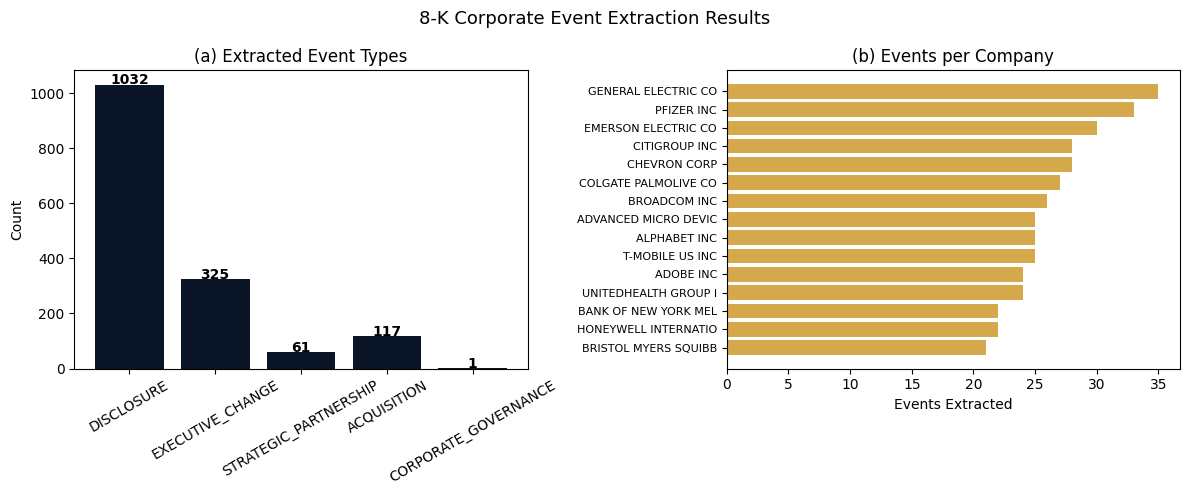

In [26]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))

# Panel (a): Event type distribution
if event_types:
    types = list(event_types.keys())
    counts = list(event_types.values())
    axes[0].bar(types, counts, color=COLORS["blue"])
    axes[0].set_ylabel("Count")
    axes[0].set_title("(a) Extracted Event Types")
    axes[0].tick_params(axis="x", rotation=30)
    for i, (t, c) in enumerate(zip(types, counts)):
        axes[0].text(i, c + 0.2, str(c), ha="center", fontweight="bold")

# Panel (b): Events per company
if companies:
    company_counts = {}
    for e in corrected_events:
        company_counts[e.subject[:20]] = company_counts.get(e.subject[:20], 0) + 1
    sorted_cos = sorted(company_counts.items(), key=lambda x: x[1], reverse=True)[:15]
    names = [n for n, _ in sorted_cos]
    cnts = [c for _, c in sorted_cos]
    axes[1].barh(range(len(names)), cnts, color=COLORS["amber"])
    axes[1].set_yticks(range(len(names)))
    axes[1].set_yticklabels(names, fontsize=8)
    axes[1].set_xlabel("Events Extracted")
    axes[1].set_title("(b) Events per Company")
    axes[1].invert_yaxis()

fig.suptitle("8-K Corporate Event Extraction Results", fontsize=13)
fig.tight_layout()
fig.show()

**Finding**: The event type distribution reflects the mix of material events
disclosed in 8-K filings. Disclosure events cover earnings, material agreements,
and financial restatements. Executive changes and acquisitions produce richer
graph structures with named entities and temporal relationships.

## 9. Neo4j Loading

Load events to Neo4j with a real database connection.

### Cypher Statement Generator

Map each event relation type to a Cypher MERGE pattern that creates or
matches the appropriate node labels and relationship types.

In [27]:
def generate_cypher_event(event: EventQuadruple) -> str:
    """Generate Cypher MERGE statement for event."""
    # Escape single quotes in names
    subject = event.subject.replace("'", "\\'")
    obj = event.object.replace("'", "\\'")

    if event.relation == "APPOINTED":
        return f"""MERGE (c:Company {{name: '{subject}'}})
MERGE (p:Person {{name: '{obj}'}})
MERGE (c)-[:APPOINTED {{effective_date: date('{event.timestamp}')}}]->(p)"""
    elif event.relation == "ACQUIRED":
        return f"""MERGE (acquirer:Company {{name: '{subject}'}})
MERGE (target:Company {{name: '{obj}'}})
MERGE (acquirer)-[:ACQUIRED {{date: date('{event.timestamp}')}}]->(target)"""
    elif event.relation == "ANNOUNCED":
        meta = event.meta_entity or "EVENT"
        return f"""MERGE (c:Company {{name: '{subject}'}})
MERGE (e:Event {{type: '{meta}', description: '{obj}'}})
SET e.date = date('{event.timestamp}')
MERGE (c)-[:ANNOUNCED]->(e)"""
    elif event.relation == "VALUED_AT":
        return f"""MERGE (e:Event {{description: '{subject}'}})
MERGE (a:Amount {{value: '{obj}'}})
MERGE (e)-[:VALUED_AT]->(a)"""
    return f"// Unsupported relation: {event.relation}"

### Batch Neo4j Loader

Use Cypher `UNWIND` to load events in batches of 500 (configurable).
This is orders of magnitude faster than individual `CREATE` statements
because it amortizes network round-trips and transaction overhead.

In [28]:
def load_event_batches(
    session,
    events: list[EventQuadruple],
    batch_size: int,
    query: str,
    mapper,
    stats: dict[str, int],
    counters: dict[str, int],
    error_label: str,
) -> None:
    """Load one relation type with UNWIND and aggregate stats."""
    for batch in batched(events, batch_size):
        try:
            session.run(query, batch=[mapper(event) for event in batch])
            stats["relationships"] += len(batch)
            for key, multiplier in counters.items():
                stats[key] += multiplier * len(batch)
        except Exception as exc:
            stats["errors"] += 1
            print(f"  {error_label} batch error: {exc}")

In [29]:
APPOINTMENT_LOAD_QUERY = """
UNWIND $batch AS row
MERGE (c:Company {name: row.subject})
MERGE (p:Person {name: row.object})
MERGE (c)-[:APPOINTED {
  effective_date: date(row.timestamp),
  public_date: date(row.public_date),
  extraction_date: date(row.extraction_date)
}]->(p)
"""
ACQUISITION_LOAD_QUERY = """
UNWIND $batch AS row
MERGE (acquirer:Company {name: row.subject})
MERGE (target:Company {name: row.object})
MERGE (acquirer)-[:ACQUIRED {
  date: date(row.timestamp),
  public_date: date(row.public_date),
  extraction_date: date(row.extraction_date)
}]->(target)
"""
ANNOUNCEMENT_LOAD_QUERY = """
UNWIND $batch AS row
MERGE (c:Company {name: row.subject})
MERGE (e:Event {type: row.meta, description: row.object})
SET e.date = date(row.timestamp)
SET e.public_date = date(row.public_date)
SET e.extraction_date = date(row.extraction_date)
MERGE (c)-[:ANNOUNCED {
  event_date: date(row.timestamp),
  public_date: date(row.public_date),
  extraction_date: date(row.extraction_date)
}]->(e)
"""

### Event Load Specs

Pair each event relation with its UNWIND query, row mapper, and counter updates.

In [30]:
def _base_event_row(event):
    """Map an event to the base Neo4j parameter dict shared across event types."""
    return {
        "subject": event.subject,
        "object": event.object,
        "timestamp": event.timestamp,
        "public_date": event.public_date or event.timestamp,
        "extraction_date": event.extraction_date or event.timestamp,
    }

In [31]:
EVENT_LOAD_SPECS = [
    (
        "APPOINTED",
        APPOINTMENT_LOAD_QUERY,
        _base_event_row,
        {"companies": 1, "persons": 1},
        "Appointment",
    ),
    ("ACQUIRED", ACQUISITION_LOAD_QUERY, _base_event_row, {"companies": 2}, "Acquisition"),
    (
        "ANNOUNCED",
        ANNOUNCEMENT_LOAD_QUERY,
        lambda event: {**_base_event_row(event), "meta": event.meta_entity or "EVENT"},
        {"companies": 1, "events": 1},
        "Announcement",
    ),
]

### Batch Neo4j Loader

Load each event type with a dedicated UNWIND template while keeping the
orchestration cell short and readable.

In [32]:
def load_events_to_neo4j_batch(events: list[EventQuadruple], batch_size: int = 500) -> dict:
    """Load events to Neo4j database using UNWIND batch loading.

    Returns stats dict with counts of loaded entities/relationships.
    """
    stats = {"companies": 0, "persons": 0, "events": 0, "relationships": 0, "errors": 0}
    if NEO4J_DRIVER is None:
        raise RuntimeError(
            "Neo4j is required for this load step. Start Neo4j and set NEO4J_URI, "
            "NEO4J_USER, and NEO4J_PASSWORD."
        )

    print("\n" + "=" * 50)
    print("BATCH LOADING TO NEO4J")
    print("=" * 50)

    with NEO4J_DRIVER.session() as session:
        constraints = [
            "CREATE CONSTRAINT IF NOT EXISTS FOR (c:Company) REQUIRE c.name IS UNIQUE",
            "CREATE CONSTRAINT IF NOT EXISTS FOR (p:Person) REQUIRE p.name IS UNIQUE",
        ]
        for constraint in constraints:
            with contextlib.suppress(Exception):
                session.run(constraint)
        for relation, query, mapper, counters, label in EVENT_LOAD_SPECS:
            relation_events = [event for event in events if event.relation == relation]
            load_event_batches(
                session, relation_events, batch_size, query, mapper, stats, counters, label
            )

    print(f"Loaded {stats['relationships']} relationships to Neo4j")
    print(
        f"  Companies: {stats['companies']}, Persons: {stats['persons']}, Events: {stats['events']}"
    )
    if stats["errors"]:
        print(f"  Errors: {stats['errors']}")

    return stats


# Keep old function for backward compatibility
load_events_to_neo4j = load_events_to_neo4j_batch

In [33]:
# Load events to Neo4j (or print Cypher if not connected)
neo4j_stats = load_events_to_neo4j(corrected_events)


BATCH LOADING TO NEO4J


Loaded 1200 relationships to Neo4j
  Companies: 1270, Persons: 181, Events: 949


## 10. Example Temporal Queries

In [34]:
print("=" * 50)
print("EXAMPLE TEMPORAL QUERIES")
print("=" * 50)

temporal_queries = {
    "Find recent executive appointments": """
MATCH (c:Company)-[a:APPOINTED]->(p:Person)
WHERE a.effective_date > date() - duration('P90D')
RETURN c.name, p.name, a.effective_date
ORDER BY a.effective_date DESC
""",
    "Find acquisition networks": """
MATCH path = (acquirer:Company)-[:ACQUIRED*1..3]->(target:Company)
RETURN acquirer.name, [n IN nodes(path) | n.name] AS chain
""",
    "Find companies with both acquisitions and exec changes": """
MATCH (c:Company)-[:ACQUIRED]->(target)
MATCH (c)-[:APPOINTED]->(p:Person)
RETURN c.name, COUNT(DISTINCT target) AS acquisitions, COUNT(DISTINCT p) AS new_execs
""",
}

for name, query in temporal_queries.items():
    print(f"\n-- {name} --")
    print(query.strip())

EXAMPLE TEMPORAL QUERIES

-- Find recent executive appointments --
MATCH (c:Company)-[a:APPOINTED]->(p:Person)
WHERE a.effective_date > date() - duration('P90D')
RETURN c.name, p.name, a.effective_date
ORDER BY a.effective_date DESC

-- Find acquisition networks --
MATCH path = (acquirer:Company)-[:ACQUIRED*1..3]->(target:Company)
RETURN acquirer.name, [n IN nodes(path) | n.name] AS chain

-- Find companies with both acquisitions and exec changes --
MATCH (c:Company)-[:ACQUIRED]->(target)
MATCH (c)-[:APPOINTED]->(p:Person)
RETURN c.name, COUNT(DISTINCT target) AS acquisitions, COUNT(DISTINCT p) AS new_execs


## 11. Summary Statistics

In [35]:
# Calculate validation metrics
initial_valid_rate = reflection_stats["initial_valid"] / len(all_events) * 100 if all_events else 0
final_valid_rate = (
    (reflection_stats["final_valid"] + reflection_stats["initial_valid"]) / len(all_events) * 100
    if all_events
    else 0
)

summary_stats = {
    "Metric": [
        "Filings processed",
        "Events extracted",
        "Executive changes",
        "Acquisitions",
        "Unique companies",
        "Unique persons",
        "Initial validation rate",
        "Post-reflection validation rate",
        "Neo4j loaded",
    ],
    "Value": [
        str(len(filing_data)),
        str(len(corrected_events)),
        str(len(appointments)),
        str(len(acquisitions)),
        str(len(companies)),
        str(len(persons)),
        f"{initial_valid_rate:.1f}%",
        f"{final_valid_rate:.1f}%",
        "Yes" if NEO4J_DRIVER else "No (Cypher printed)",
    ],
}

summary_df = pl.DataFrame(summary_stats)
print("\n" + "=" * 50)
print("NOTEBOOK RESULTS FOR CHAPTER 23.7")
print("=" * 50)
print(summary_df)


NOTEBOOK RESULTS FOR CHAPTER 23.7
shape: (9, 2)
┌─────────────────────────────────┬───────┐
│ Metric                          ┆ Value │
│ ---                             ┆ ---   │
│ str                             ┆ str   │
╞═════════════════════════════════╪═══════╡
│ Filings processed               ┆ 1249  │
│ Events extracted                ┆ 1536  │
│ Executive changes               ┆ 181   │
│ Acquisitions                    ┆ 70    │
│ Unique companies                ┆ 186   │
│ Unique persons                  ┆ 158   │
│ Initial validation rate         ┆ 87.8% │
│ Post-reflection validation rat… ┆ 97.0% │
│ Neo4j loaded                    ┆ Yes   │
└─────────────────────────────────┴───────┘


**Interpretation**: The high post-reflection validation rate shows that the
critic-corrector loop effectively normalizes LLM output to schema-compliant
quadruples. In production, the remaining invalid events (if any) would be
flagged for manual review. The event type distribution reflects the natural
skew in 8-K filings: executive changes are the most common material event,
while acquisitions carry the highest information content for downstream
alpha signals.

## 12. Verification

In [36]:
print("\n" + "=" * 50)
print("NOTEBOOK EXECUTION COMPLETE")
print("=" * 50)
print(f"Mode: Preloaded 8-K data ({len(filing_data)} filings)")
print("Data source: load_sec_filings('8-K', universe='sp100')")
print(f"LLM: {'Qwen2.5-7B (GPU)' if LLM_MODEL else 'Not available'}")
print(f"Neo4j: {'Connected' if NEO4J_DRIVER else 'Not available'}")
print(f"Filings: {len(filing_data)}")
print(f"Events: {len(corrected_events)}")
print(f"Validation improvement: {initial_valid_rate:.1f}% -> {final_valid_rate:.1f}%")
print("\nFinReflectKG methodology implemented: CheckRules + Critic-Corrector loop.")


NOTEBOOK EXECUTION COMPLETE
Mode: Preloaded 8-K data (1249 filings)
Data source: load_sec_filings('8-K', universe='sp100')
LLM: Qwen2.5-7B (GPU)
Neo4j: Connected
Filings: 1249
Events: 1536
Validation improvement: 87.8% -> 97.0%

FinReflectKG methodology implemented: CheckRules + Critic-Corrector loop.


## Key Takeaways

1. **Structured prompting with CheckRules** embeds schema constraints directly in
   the LLM system prompt, reducing post-extraction corrections by enforcing
   uppercase entities, valid relation types, and length limits upfront.
2. **The critic-corrector reflection loop** (FinReflectKG) catches remaining
   violations deterministically, achieving near-100% schema compliance within
   2--3 iterations without additional LLM calls.
3. **Batch inference** (processing multiple filings per forward pass) provides
   roughly linear throughput gains, making S&P 100-scale extraction feasible on
   a single GPU in minutes rather than hours.
4. **Neo4j UNWIND batch loading** is critical at scale -- individual MERGE
   statements would bottleneck on network round-trips long before the graph
   size becomes a concern.
5. **Temporal Cypher queries** over the event graph enable multi-hop reasoning
   (e.g., "companies with both acquisitions and executive changes in Q3 2024")
   that would be impossible with vector-only retrieval.

**Next**: See `institutional_holdings_kg` for building ownership graphs from
13F filings, and `dynamic_kg_temporal` for tracking how these event graphs
evolve over time.